# Indian Two-Wheeler Market Assessment
### Capstone Assignment 20.1 — Initial Report & Exploratory Data Analysis (EDA)

**Research Question:** Which factors most significantly predict two-wheeler sales volume and resale value across Indian states, and can a machine learning model reliably forecast regional demand by brand and model segment?

**Data source:** `bike_sales_india.csv` — user-provided Indian two-wheeler sales dataset (10,000 records, 15 columns: State, Avg Daily Distance, Brand, Model, Price, Year of Manufacture, Engine Capacity, Fuel Type, Mileage, Owner Type, Registration Year, Insurance Status, Seller Type, Resale Price, City Tier).

**Notebook contents**
1. Setup & Data Loading
2. Data Cleaning
3. Feature Engineering
4. Exploratory Data Analysis
5. Baseline Regression Model — Resale Price
6. Ensemble Regression Models (Bagging, Random Forest, Gradient Boosting)
7. Classification — High vs. Low Demand Segments
8. Clustering — State Buyer-Behavior Segments
9. Feature Importance & Key Takeaways


## 1. Setup & Data Loading

In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn

  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl (5.3 MB)
  Using cached pandas-2.3.3-cp39-cp39-macosx_11_0_arm64.whl (10.8 MB)
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl (7.8 MB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached scikit_learn-1.6.1-cp39-cp39-macosx_12_0_arm64.whl (11.1 MB)
  Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl (249 kB)
  Using cached pillow-11.3.0-cp39-cp39-macosx_11_0_arm64.whl (4.7 MB)
  Using cached fonttools-4.60.2-cp39-cp39-macosx_10_9_universal2.whl (2.9 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl (64 kB)
  Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl (30.3 MB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
  Usin

In [3]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    BaggingRegressor, GradientBoostingRegressor,
    AdaBoostClassifier, GradientBoostingClassifier,
)
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42


In [4]:
# Load dataset
df = pd.read_csv("../data/bike_sales_india.csv")

print(f"Shape: {df.shape}")
df.head()


Shape: (10000, 15)


,State,Avg Daily Distance (km),Brand,Model,Price (INR),Year of Manufacture,Engine Capacity (cc),Fuel Type,Mileage (km/l),Owner Type,Registration Year,Insurance Status,Seller Type,Resale Price (INR),City Tier
0,Karnataka,68.84,Royal Enfield,Hunter 350,252816,2021,672,Electric,78.41,Second,2024,Active,Individual,149934.18,Tier 3
1,Rajasthan,23.80,Bajaj,Dominar 400,131100,2020,769,Hybrid,89.98,Third,2023,Active,Individual,66960.30,Tier 3
2,Madhya Pradesh,27.67,KTM,125 Duke,201016,2020,216,Hybrid,71.46,Second,2023,Active,Dealer,141522.64,Tier 3
3,Karnataka,62.85,Kawasaki,Ninja 300,132482,2021,556,Petrol,51.73,Third,2021,Active,Dealer,56057.22,Tier 1
4,Madhya Pradesh,10.62,Yamaha,FZ V3,231796,2019,298,Petrol,54.72,Third,2019,Not Available,Individual,132538.36,Tier 3


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   State                    10000 non-null  object 
 1   Avg Daily Distance (km)  10000 non-null  float64
 2   Brand                    10000 non-null  object 
 3   Model                    10000 non-null  object 
 4   Price (INR)              10000 non-null  int64  
 5   Year of Manufacture      10000 non-null  int64  
 6   Engine Capacity (cc)     10000 non-null  int64  
 7   Fuel Type                10000 non-null  object 
 8   Mileage (km/l)           10000 non-null  float64
 9   Owner Type               10000 non-null  object 
 10  Registration Year        10000 non-null  int64  
 11  Insurance Status         10000 non-null  object 
 12  Seller Type              10000 non-null  object 
 13  Resale Price (INR)       10000 non-null  float64
 14  City Tier              

In [6]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State,10000,10,Punjab,1051,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Avg Daily Distance (km),10000.0,NaN,NaN,NaN,42.533128,21.676985,5.01,23.9075,42.48,61.3525,80.0
Brand,10000,8,Kawasaki,1291,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,10000,40,Ray ZR,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (INR),10000.0,NaN,NaN,NaN,224328.7224,100753.660447,50031.0,137900.25,223878.0,311464.25,399981.0
Year of Manufacture,10000.0,NaN,NaN,NaN,2019.5105,2.907668,2015.0,2017.0,2019.0,2022.0,2024.0
Engine Capacity (cc),10000.0,NaN,NaN,NaN,552.6953,261.176292,100.0,327.0,553.0,780.0,1000.0
Fuel Type,10000,3,Hybrid,3360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mileage (km/l),10000.0,NaN,NaN,NaN,67.188926,20.891728,25.0,50.68,69.85,84.5425,100.0
Owner Type,10000,3,First,3407,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Cleaning

Steps performed:
- Standardize column names to snake_case and text fields (strip whitespace, normalize casing)
- Check for and remove exact duplicate records
- Audit and impute missing values (median for numeric, mode for categorical)
- Validate logical consistency (resale price should not exceed original price; registration year should not precede manufacture year)
- Detect and cap outliers in price, resale price, average daily distance, and mileage using the IQR method


In [7]:
# --- Standardize column names ---
df.columns = (
    df.columns.str.strip()
    .str.replace(r"\s*\(.*?\)", "", regex=True)   # drop unit suffixes like "(km)", "(INR)"
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
print(df.columns.tolist())


['state', 'avg_daily_distance', 'brand', 'model', 'price', 'year_of_manufacture', 'engine_capacity', 'fuel_type', 'mileage', 'owner_type', 'registration_year', 'insurance_status', 'seller_type', 'resale_price', 'city_tier']


In [8]:
# --- Standardize text columns ---
text_cols = ["state", "brand", "model", "fuel_type", "owner_type", "insurance_status", "seller_type", "city_tier"]
for c in text_cols:
    df[c] = df[c].astype(str).str.strip().str.title()

print("States:", sorted(df['state'].unique()))
print("Brands:", sorted(df['brand'].unique()))
print("Fuel types:", sorted(df['fuel_type'].unique()))


States: ['Delhi', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Uttar Pradesh', 'West Bengal']
Brands: ['Bajaj', 'Hero', 'Honda', 'Kawasaki', 'Ktm', 'Royal Enfield', 'Tvs', 'Yamaha']
Fuel types: ['Electric', 'Hybrid', 'Petrol']


In [9]:
# --- Duplicate removal ---
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)
print(f"Removed {n_before - n_after} duplicate rows ({n_before} -> {n_after})")


Removed 0 duplicate rows (10000 -> 10000)


In [10]:
# --- Missing value audit ---
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0")
print("Columns with missing values:" if len(missing_report) else "No missing values found.")
missing_report


No missing values found.


,missing_count,missing_pct


In [11]:
# --- Impute missing values (defensive — none found in this dataset, but kept for pipeline robustness) ---
num_cols_impute = ["avg_daily_distance", "resale_price", "engine_capacity", "mileage", "price"]
for c in num_cols_impute:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

for c in ["insurance_status", "owner_type", "seller_type", "city_tier"]:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].mode()[0])

assert df.isna().sum().sum() == 0, "Missing values remain!"
print("Missing-value pass complete. Remaining NA count:", df.isna().sum().sum())


Missing-value pass complete. Remaining NA count: 0


In [12]:
# --- Logical consistency checks ---
bad_resale = (df["resale_price"] > df["price"]).sum()
bad_years = (df["registration_year"] < df["year_of_manufacture"]).sum()
print(f"Records where resale price exceeds original price: {bad_resale}")
print(f"Records where registration year precedes manufacture year: {bad_years}")

# Drop/fix any that do occur (defensive, dataset currently passes both checks)
df = df[df["resale_price"] <= df["price"]]
df = df[df["registration_year"] >= df["year_of_manufacture"]]
print(f"Rows remaining after consistency filtering: {len(df)}")


Records where resale price exceeds original price: 0
Records where registration year precedes manufacture year: 0
Rows remaining after consistency filtering: 10000


In [13]:
# --- Outlier detection & capping (IQR method) ---
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_summary = {}
for col in ["avg_daily_distance", "resale_price", "price", "mileage"]:
    lo, hi = iqr_bounds(df[col])
    n_outliers = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary[col] = {"lower": round(lo, 1), "upper": round(hi, 1), "n_outliers": int(n_outliers)}
    df[col] = df[col].clip(lower=lo, upper=hi)

pd.DataFrame(outlier_summary).T


,lower,upper,n_outliers
avg_daily_distance,-32.3,117.5,0.0
resale_price,-74870.0,334599.1,0.0
price,-122445.8,571810.2,0.0
mileage,-0.1,135.3,0.0


## 3. Feature Engineering

New features derived from the raw columns:
- `vehicle_age_years` — from registration year
- `resale_ratio` — resale price as a fraction of original price (depreciation benchmark)
- `segment` — body-style segment (Commuter / Sports / Cruiser / Superbike) inferred from engine capacity, since the raw data has no explicit body-style column; electric vehicles are grouped separately
- `usage_band` — categorical bucket of average daily distance (Low / Medium / High)
- `price_band` — categorical bucket of purchase price (Economy / Mid / Premium), using quantile cuts
- `is_electric` — binary flag for EV powertrain
- `high_demand` — binary label: 1 if a (state, brand, segment) combination sells above the median volume for that state, else 0 — used as the classification target


In [14]:
current_year = 2026
df["vehicle_age_years"] = current_year - df["registration_year"]
df["resale_ratio"] = (df["resale_price"] / df["price"]).round(3)

df["usage_band"] = pd.cut(
    df["avg_daily_distance"], bins=[-1, 25, 55, 1000],
    labels=["Low", "Medium", "High"]
)

df["price_band"] = pd.qcut(df["price"], q=3, labels=["Economy", "Mid", "Premium"])

df["is_electric"] = (df["fuel_type"] == "Electric").astype(int)

def infer_segment(row):
    if row["fuel_type"] == "Electric":
        return "Electric"
    cc = row["engine_capacity"]
    if cc <= 250:
        return "Commuter"
    elif cc <= 500:
        return "Sports"
    elif cc <= 750:
        return "Cruiser"
    else:
        return "Superbike"

df["segment"] = df.apply(infer_segment, axis=1)

df[["vehicle_age_years", "resale_ratio", "usage_band", "price_band", "is_electric", "segment"]].head()


,vehicle_age_years,resale_ratio,usage_band,price_band,is_electric,segment
0,2,0.593,High,Mid,1,Electric
1,3,0.511,Low,Economy,0,Superbike
2,3,0.704,Medium,Mid,0,Commuter
3,5,0.423,High,Economy,0,Cruiser
4,7,0.572,Low,Mid,0,Sports


In [15]:
# --- Demand label: sales volume per (state, brand, segment) combo ---
demand_counts = (
    df.groupby(["state", "brand", "segment"], observed=True)
    .size()
    .reset_index(name="combo_sales_volume")
)
state_median = demand_counts.groupby("state")["combo_sales_volume"].transform("median")
demand_counts["high_demand"] = (demand_counts["combo_sales_volume"] > state_median).astype(int)

df = df.merge(demand_counts, on=["state", "brand", "segment"], how="left")
print(df["high_demand"].value_counts(normalize=True).round(3))
df[["state", "brand", "segment", "combo_sales_volume", "high_demand"]].head()


high_demand
1    0.628
0    0.372
Name: proportion, dtype: float64


,state,brand,segment,combo_sales_volume,high_demand
0,Karnataka,Royal Enfield,Electric,42,1
1,Rajasthan,Bajaj,Superbike,28,1
2,Madhya Pradesh,Ktm,Commuter,10,0
3,Karnataka,Kawasaki,Cruiser,28,1
4,Madhya Pradesh,Yamaha,Sports,37,1


## 4. Exploratory Data Analysis

### 4.1 Regional Sales Distribution


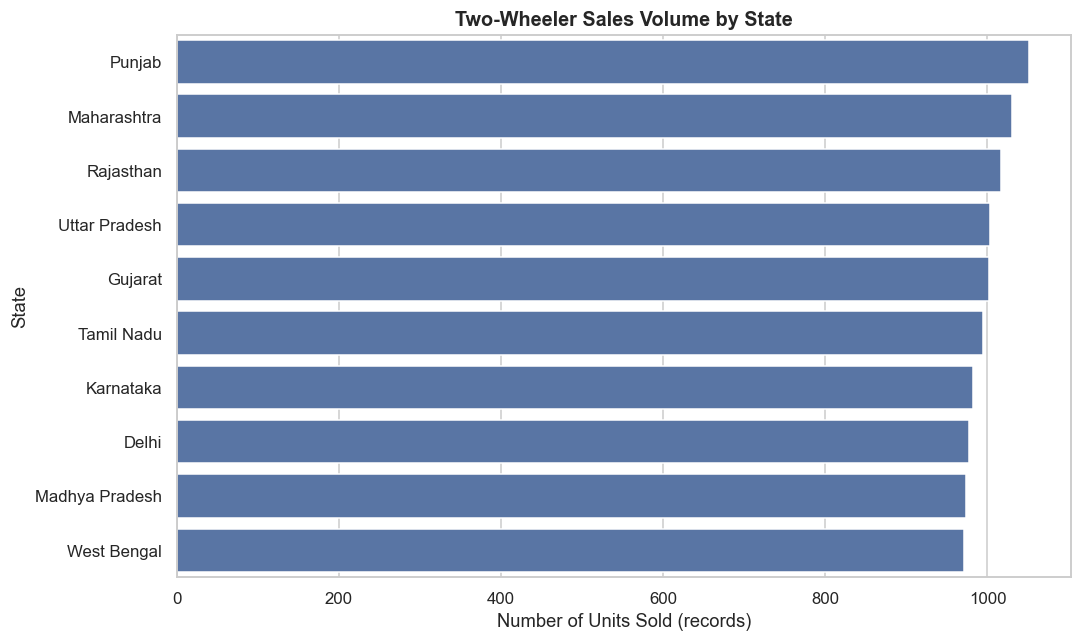

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
state_order = df["state"].value_counts().index
sns.countplot(data=df, y="state", order=state_order, ax=ax, color="#4C72B0")
ax.set_title("Two-Wheeler Sales Volume by State", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Units Sold (records)")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()


### 4.2 Brand Market Share

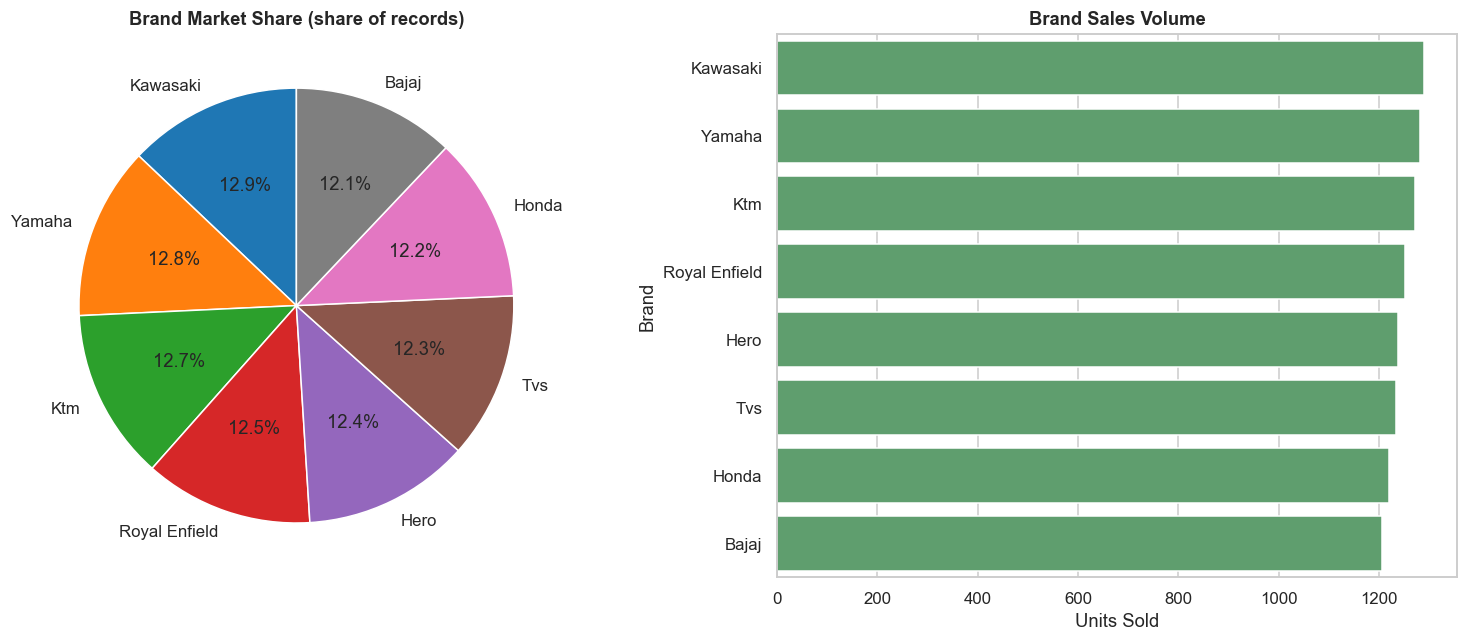

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

brand_counts = df["brand"].value_counts()
axes[0].pie(brand_counts.values, labels=brand_counts.index, autopct="%1.1f%%",
            startangle=90, colors=sns.color_palette("tab10", len(brand_counts)))
axes[0].set_title("Brand Market Share (share of records)", fontsize=12, fontweight="bold")

sns.barplot(x=brand_counts.values, y=brand_counts.index, ax=axes[1], color="#55A868")
axes[1].set_title("Brand Sales Volume", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Units Sold")
axes[1].set_ylabel("Brand")

plt.tight_layout()
plt.show()


### 4.3 Price Distribution & Clustering by Segment

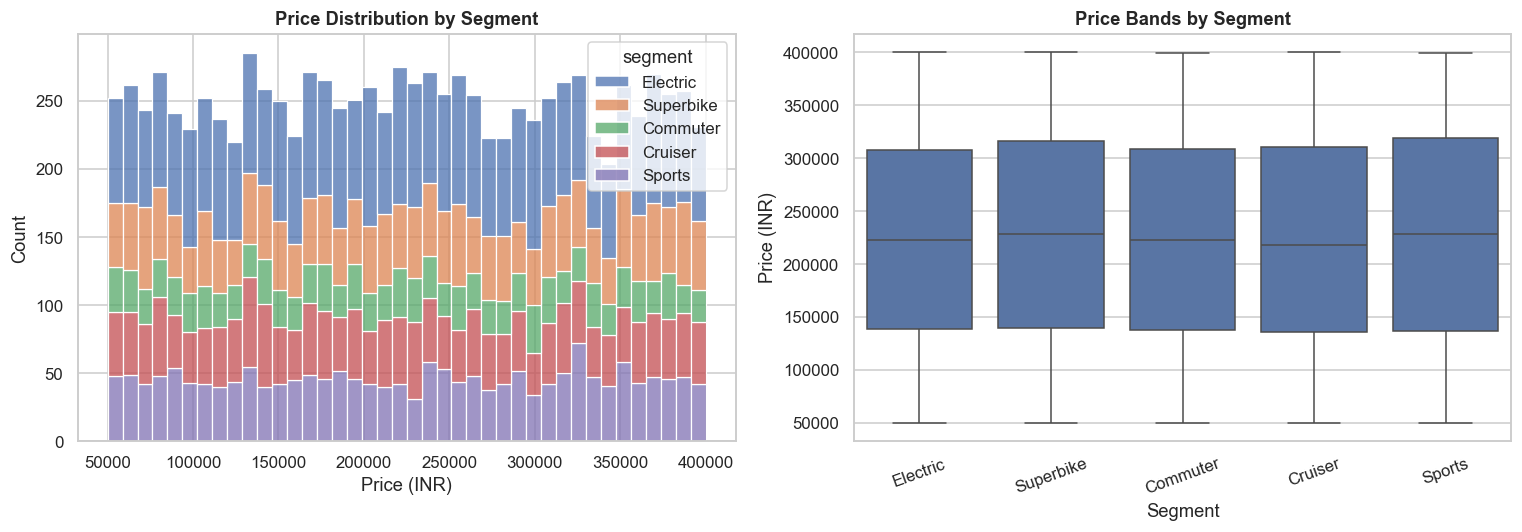

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="price", hue="segment", multiple="stack", bins=40, ax=axes[0])
axes[0].set_title("Price Distribution by Segment", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Price (INR)")

sns.boxplot(data=df, x="segment", y="price", ax=axes[1])
axes[1].set_title("Price Bands by Segment", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Price (INR)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


### 4.4 Resale Value vs. Vehicle Age

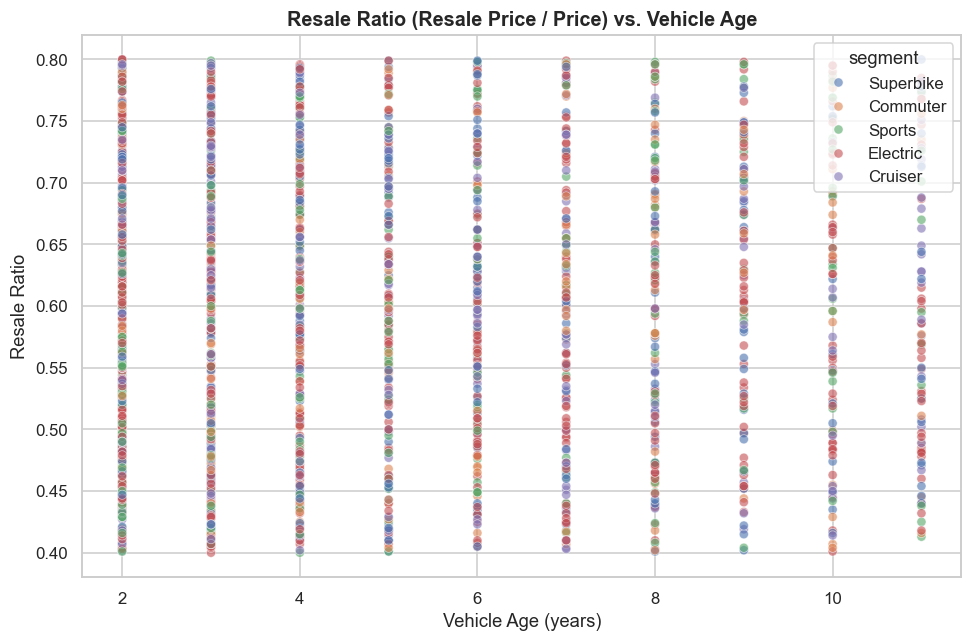

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=df.sample(2000, random_state=RANDOM_STATE),
    x="vehicle_age_years", y="resale_ratio", hue="segment", alpha=0.6, ax=ax
)
ax.set_title("Resale Ratio (Resale Price / Price) vs. Vehicle Age", fontsize=13, fontweight="bold")
ax.set_xlabel("Vehicle Age (years)")
ax.set_ylabel("Resale Ratio")
plt.tight_layout()
plt.show()


### 4.5 Fuel Type, Insurance Status & Ownership

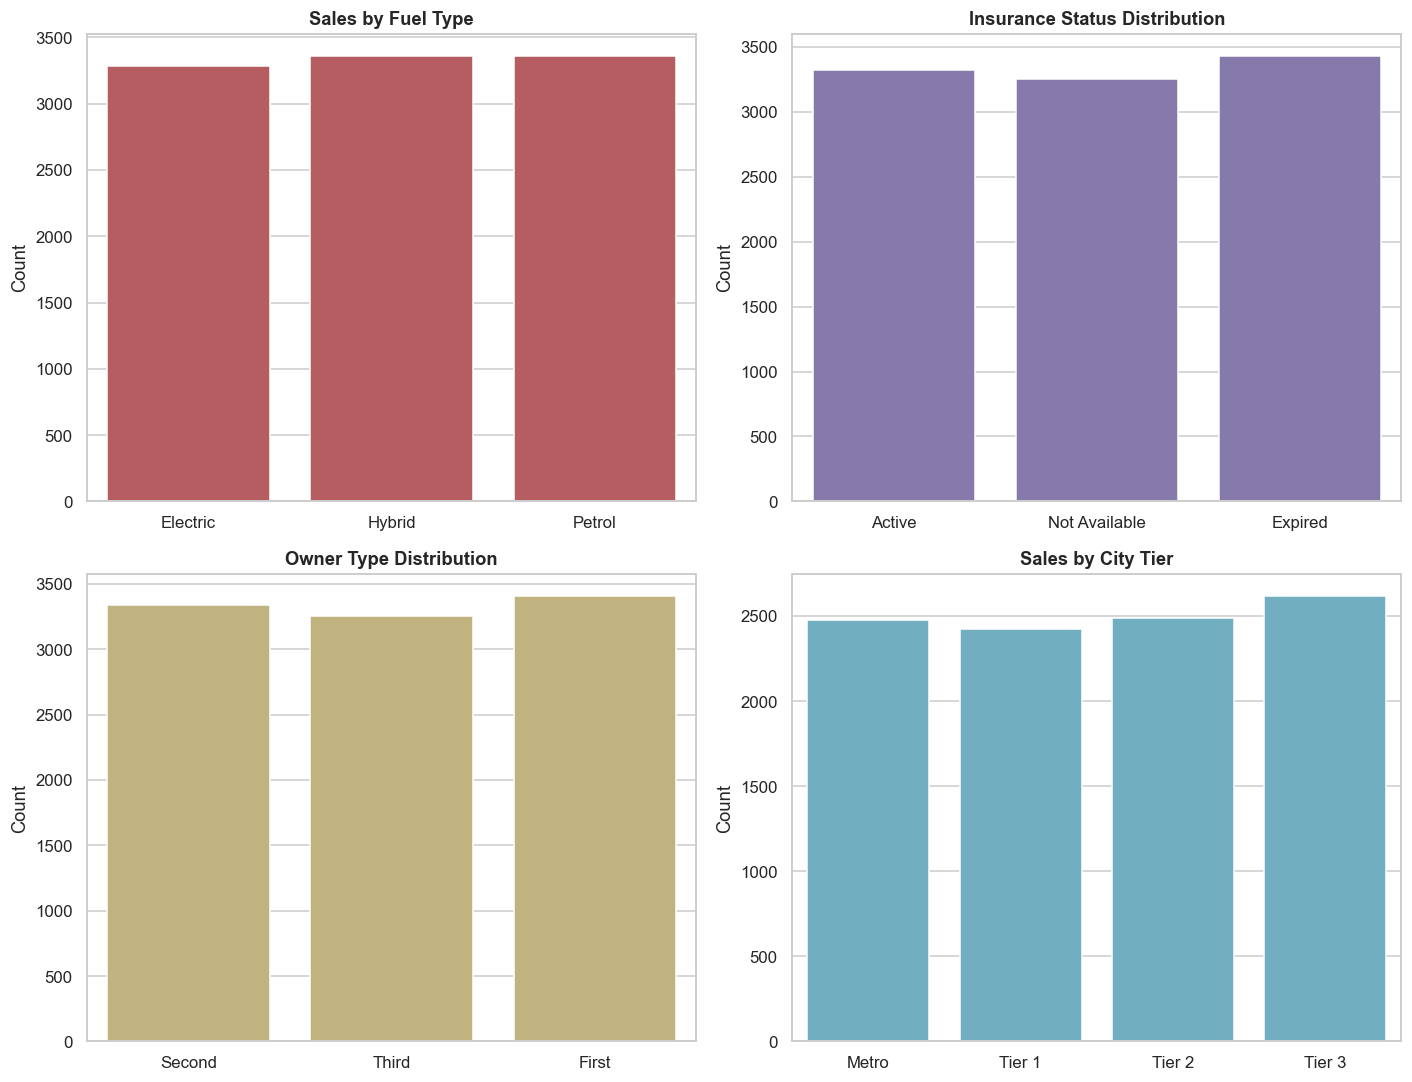

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.countplot(data=df, x="fuel_type", ax=axes[0, 0], color="#C44E52")
axes[0, 0].set_title("Sales by Fuel Type", fontsize=12, fontweight="bold")

sns.countplot(data=df, x="insurance_status", ax=axes[0, 1], color="#8172B2")
axes[0, 1].set_title("Insurance Status Distribution", fontsize=12, fontweight="bold")

sns.countplot(data=df, x="owner_type", ax=axes[1, 0], color="#CCB974")
axes[1, 0].set_title("Owner Type Distribution", fontsize=12, fontweight="bold")

sns.countplot(data=df, x="city_tier", ax=axes[1, 1], color="#64B5CD",
              order=["Metro", "Tier 1", "Tier 2", "Tier 3"])
axes[1, 1].set_title("Sales by City Tier", fontsize=12, fontweight="bold")

for ax_row in axes:
    for ax in ax_row:
        ax.set_xlabel("")
        ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


### 4.6 Correlation Heatmap (numeric features)

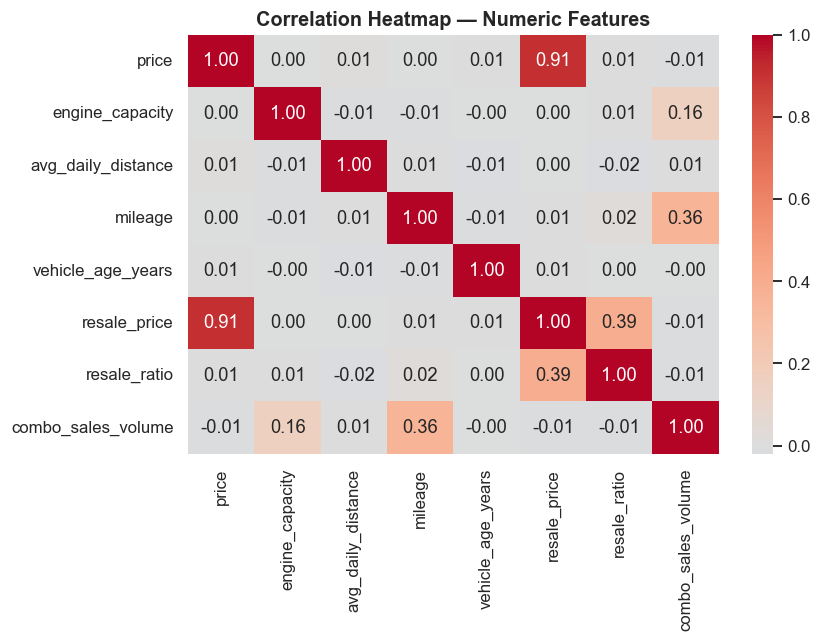

In [21]:
numeric_cols = ["price", "engine_capacity", "avg_daily_distance", "mileage", "vehicle_age_years",
                 "resale_price", "resale_ratio", "combo_sales_volume"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap — Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 4.7 Average Resale Price by State (Regional Demand Map Proxy)

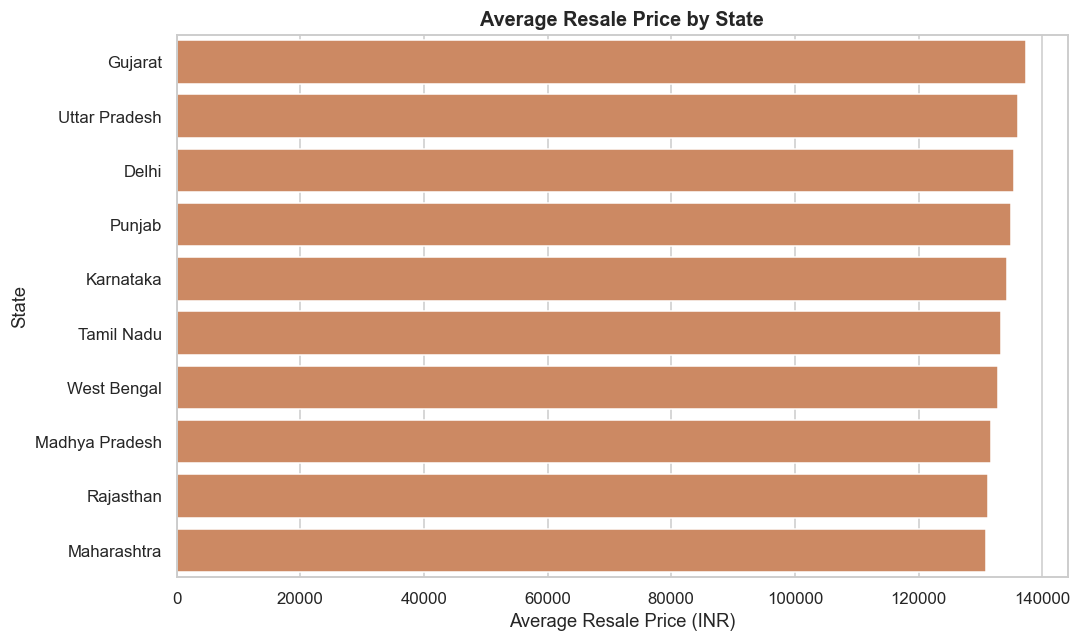

In [22]:
state_resale = df.groupby("state", observed=True)["resale_price"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=state_resale.values, y=state_resale.index, ax=ax, color="#DD8452")
ax.set_title("Average Resale Price by State", fontsize=13, fontweight="bold")
ax.set_xlabel("Average Resale Price (INR)")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()


## 5. Baseline Regression Model — Resale Price

**Target:** `resale_price` (continuous)
**Baseline model:** Linear Regression
**Evaluation metrics:** RMSE, MAE, R²
- **RMSE** is reported in INR, so stakeholders (dealers/manufacturers) can read the typical prediction error directly in rupee terms.
- **R²** communicates the proportion of variance in resale price explained by the model, useful for comparing model quality across iterations.
- **MAE** is included because it is less sensitive to a handful of large-value outliers still present in resale price, giving a more "typical case" error alongside RMSE.


In [23]:
feature_cols = ["brand", "segment", "state", "fuel_type", "price", "engine_capacity",
                 "avg_daily_distance", "mileage", "vehicle_age_years", "insurance_status",
                 "owner_type", "seller_type", "city_tier", "price_band"]
target_col = "resale_price"

X = df[feature_cols].copy()
y = df[target_col].copy()

cat_cols = ["brand", "segment", "state", "fuel_type", "insurance_status",
            "owner_type", "seller_type", "city_tier", "price_band"]
num_cols = ["price", "engine_capacity", "avg_daily_distance", "mileage", "vehicle_age_years"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (8000, 14), Test: (2000, 14)


In [24]:
def evaluate_regressor(name, model, X_train, X_test, y_train, y_test):
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    return pipe, {"model": name, "RMSE": round(rmse, 0), "MAE": round(mae, 0), "R2": round(r2, 3)}

lin_pipe, lin_results = evaluate_regressor("Linear Regression (baseline)", LinearRegression(),
                                            X_train, X_test, y_train, y_test)
lin_results


/Users/avirup/Desktop/UCB-AIMLrepo/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/avirup/Desktop/UCB-AIMLrepo/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/avirup/Desktop/UCB-AIMLrepo/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


{'model': 'Linear Regression (baseline)',
 'RMSE': 28929.0,
 'MAE': 22702.0,
 'R2': 0.809}

## 6. Ensemble Regression Models

Three ensemble techniques are compared against the linear-regression baseline:
- **Bagging Regressor** (bootstrap-aggregated decision trees) — reduces variance vs. a single tree
- **Random Forest Regressor** — bagging + random feature subsetting, typically the strongest all-round tabular baseline
- **Gradient Boosting Regressor** — sequential boosting, often the best fit for structured/tabular data with non-linear interactions (e.g., price × brand × age effects on resale value)


In [25]:
bag_pipe, bag_results = evaluate_regressor(
    "Bagging Regressor",
    BaggingRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    X_train, X_test, y_train, y_test
)

rf_pipe, rf_results = evaluate_regressor(
    "Random Forest Regressor",
    RandomForestRegressor(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    X_train, X_test, y_train, y_test
)

gb_pipe, gb_results = evaluate_regressor(
    "Gradient Boosting Regressor",
    GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE),
    X_train, X_test, y_train, y_test
)

reg_results_df = pd.DataFrame([lin_results, bag_results, rf_results, gb_results]).sort_values("RMSE")
reg_results_df


,model,RMSE,MAE,R2
0,Linear Regression (baseline),28929.0,22702.0,0.809
3,Gradient Boosting Regressor,29007.0,22751.0,0.808
2,Random Forest Regressor,29369.0,22965.0,0.804
1,Bagging Regressor,29582.0,23089.0,0.801


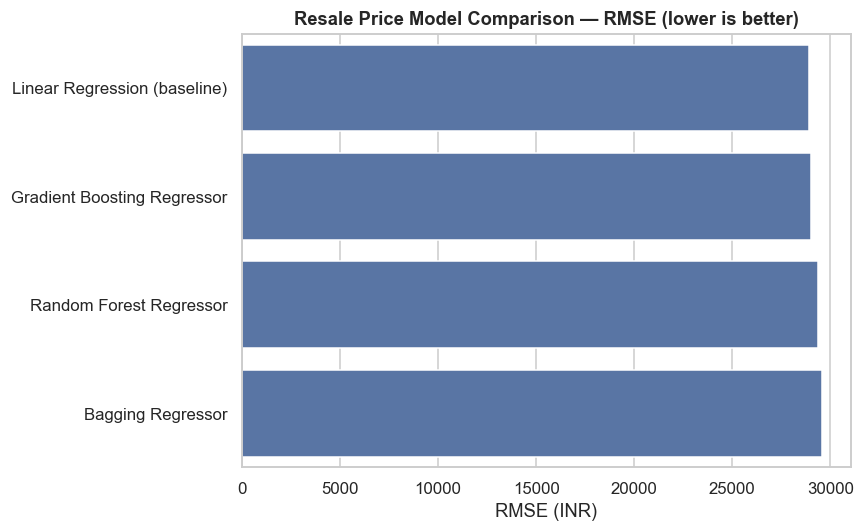

Best regression model: Linear Regression (baseline)


In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=reg_results_df, x="RMSE", y="model", ax=ax, color="#4C72B0")
ax.set_title("Resale Price Model Comparison — RMSE (lower is better)", fontsize=12, fontweight="bold")
ax.set_xlabel("RMSE (INR)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

best_reg_name = reg_results_df.iloc[0]["model"]
print(f"Best regression model: {best_reg_name}")


## 7. Classification — High vs. Low Demand Segments

**Target:** `high_demand` (1 = above-median sales volume for that state/brand/segment combination, 0 = below)
**Models compared:** Logistic Regression (baseline), Decision Tree, Random Forest, AdaBoost, Gradient Boosting
**Evaluation metrics:** Accuracy, F1-score, ROC-AUC
- **F1-score** is the primary metric because it balances false "high-demand" calls (overstock risk) against false "low-demand" calls (lost-sale risk) — directly relevant to a dealer's inventory decision.
- **ROC-AUC** assesses ranking quality independent of the classification threshold, useful since a dealer may want to tune the cutoff.
- **Accuracy** is included as an intuitive baseline sanity check.

**Note on features:** `high_demand` is derived from a groupby on `(state, brand, segment)`, so those three columns are excluded from the model's inputs — including them would let a model memorize the label rather than learn a genuine relationship (label leakage). The classifier instead predicts demand tier from the vehicle/customer attributes a dealer would actually observe at the point of sale.


In [27]:
clf_feature_cols = ["fuel_type", "price", "engine_capacity", "avg_daily_distance", "mileage",
                     "vehicle_age_years", "insurance_status", "owner_type", "seller_type", "city_tier"]
Xc = df[clf_feature_cols].copy()
yc = df["high_demand"].copy()

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc
)

clf_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["price", "engine_capacity", "avg_daily_distance", "mileage", "vehicle_age_years"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["fuel_type", "insurance_status", "owner_type", "seller_type", "city_tier"]),
])

def evaluate_classifier(name, model):
    pipe = Pipeline([("prep", clf_preprocessor), ("model", model)])
    pipe.fit(Xc_train, yc_train)
    preds = pipe.predict(Xc_test)
    proba = pipe.predict_proba(Xc_test)[:, 1] if hasattr(pipe.named_steps["model"], "predict_proba") else None
    acc = accuracy_score(yc_test, preds)
    f1 = f1_score(yc_test, preds)
    auc = roc_auc_score(yc_test, proba) if proba is not None else np.nan
    return pipe, {"model": name, "Accuracy": round(acc, 3), "F1": round(f1, 3), "ROC_AUC": round(auc, 3)}

log_pipe, log_results = evaluate_classifier("Logistic Regression (baseline)", LogisticRegression(max_iter=1000))
dt_pipe, dt_results = evaluate_classifier("Decision Tree", DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE))
rfc_pipe, rfc_results = evaluate_classifier("Random Forest", RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1))
ada_pipe, ada_results = evaluate_classifier("AdaBoost", AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE))
gbc_pipe, gbc_results = evaluate_classifier("Gradient Boosting", GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE))

clf_results_df = pd.DataFrame([log_results, dt_results, rfc_results, ada_results, gbc_results]).sort_values("F1", ascending=False)
clf_results_df


/Users/avirup/Desktop/UCB-AIMLrepo/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/avirup/Desktop/UCB-AIMLrepo/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/avirup/Desktop/UCB-AIMLrepo/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/avirup/Desktop/UCB-AIMLrepo/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/avirup/Desktop/UCB-AIMLrepo/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in 

,model,Accuracy,F1,ROC_AUC
4,Gradient Boosting,0.752,0.810,0.861
2,Random Forest,0.743,0.805,0.854
0,Logistic Regression (baseline),0.738,0.788,0.849
3,AdaBoost,0.753,0.786,0.859
1,Decision Tree,0.743,0.781,0.857


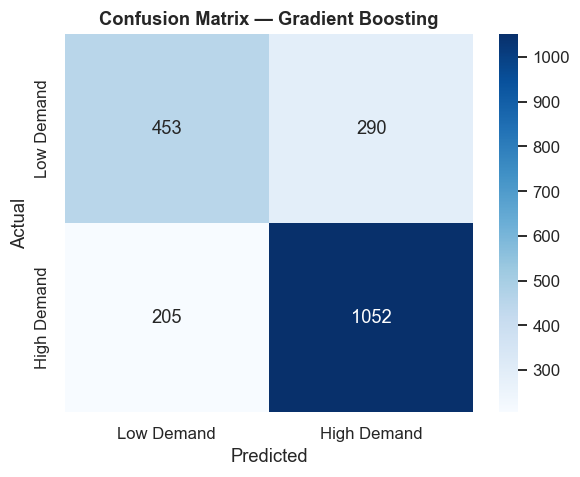

              precision    recall  f1-score   support

  Low Demand       0.69      0.61      0.65       743
 High Demand       0.78      0.84      0.81      1257

    accuracy                           0.75      2000
   macro avg       0.74      0.72      0.73      2000
weighted avg       0.75      0.75      0.75      2000



In [28]:
best_clf_name = clf_results_df.iloc[0]["model"]
best_clf_pipe = {"Logistic Regression (baseline)": log_pipe, "Decision Tree": dt_pipe,
                  "Random Forest": rfc_pipe, "AdaBoost": ada_pipe,
                  "Gradient Boosting": gbc_pipe}[best_clf_name]

preds = best_clf_pipe.predict(Xc_test)
cm = confusion_matrix(yc_test, preds)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Low Demand", "High Demand"], yticklabels=["Low Demand", "High Demand"])
ax.set_title(f"Confusion Matrix — {best_clf_name}", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(yc_test, preds, target_names=["Low Demand", "High Demand"]))


## 8. Clustering — State Buyer-Behavior Segments (K-Means)

States are clustered on aggregated buyer-behavior features (average price, average daily distance, average resale ratio, share of electric vehicles, and average vehicle age) to identify distinct regional demand profiles.


In [29]:
state_profile = df.groupby("state", observed=True).agg(
    avg_price=("price", "mean"),
    avg_daily_distance=("avg_daily_distance", "mean"),
    avg_resale_ratio=("resale_ratio", "mean"),
    pct_electric=("is_electric", "mean"),
    avg_vehicle_age=("vehicle_age_years", "mean"),
).reset_index()

scaler = StandardScaler()
X_state = scaler.fit_transform(state_profile.drop(columns="state"))

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
state_profile["cluster"] = kmeans.fit_predict(X_state)

state_profile.sort_values("cluster")


,state,avg_price,avg_daily_distance,avg_resale_ratio,pct_electric,avg_vehicle_age,cluster
1,Gujarat,226440.647705,41.627814,0.605038,0.316367,5.043912,0
2,Karnataka,225220.251527,42.746925,0.596881,0.337067,4.940937,1
3,Madhya Pradesh,219936.943474,42.866033,0.598888,0.340185,4.857143,1
4,Maharashtra,220031.651456,42.134282,0.594375,0.322330,4.989320,1
5,Punjab,226566.136061,42.831931,0.594852,0.348240,5.019029,1
6,Rajasthan,220819.930187,43.149882,0.595762,0.336283,4.910521,1
9,West Bengal,221925.126674,42.698723,0.598157,0.322348,5.011329,1
0,Delhi,228109.786080,41.336192,0.593029,0.322416,5.215967,2
7,Tamil Nadu,226715.380282,42.998189,0.588148,0.322938,5.143863,2
8,Uttar Pradesh,227511.102692,42.921097,0.597575,0.314058,5.218345,2


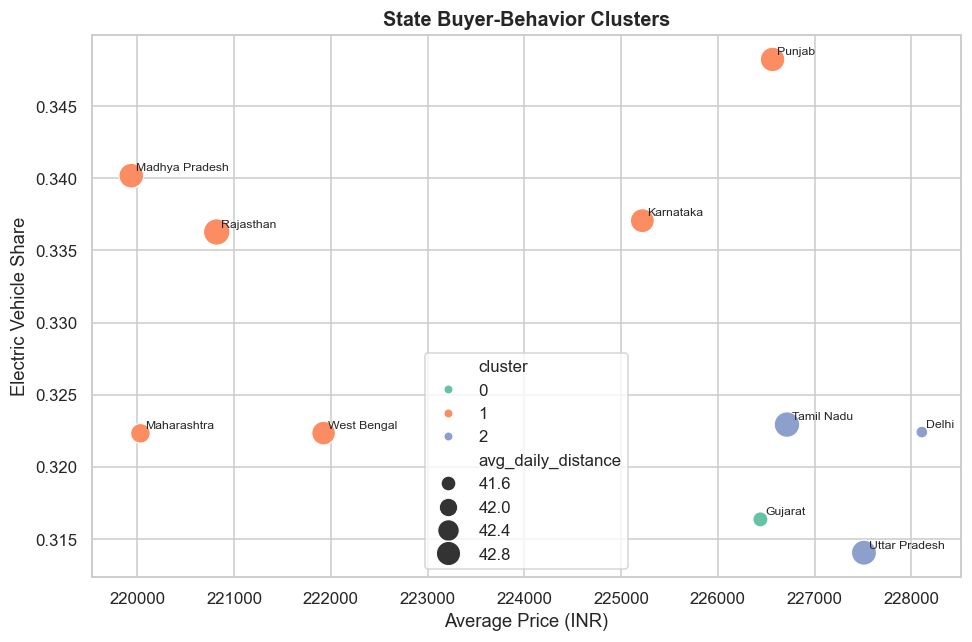

In [30]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=state_profile, x="avg_price", y="pct_electric",
    hue="cluster", size="avg_daily_distance", sizes=(60, 300), palette="Set2", ax=ax
)
for _, row in state_profile.iterrows():
    ax.annotate(row["state"], (row["avg_price"], row["pct_electric"]), fontsize=8, xytext=(3, 3), textcoords="offset points")

ax.set_title("State Buyer-Behavior Clusters", fontsize=13, fontweight="bold")
ax.set_xlabel("Average Price (INR)")
ax.set_ylabel("Electric Vehicle Share")
plt.tight_layout()
plt.show()


## 9. Feature Importance & Key Takeaways


In [29]:
best_reg_pipe = {"Linear Regression (baseline)": lin_pipe, "Bagging Regressor": bag_pipe,
                  "Random Forest Regressor": rf_pipe, "Gradient Boosting Regressor": gb_pipe}[best_reg_name]

if hasattr(best_reg_pipe.named_steps["model"], "feature_importances_"):
    feat_names = best_reg_pipe.named_steps["prep"].get_feature_names_out()
    importances = best_reg_pipe.named_steps["model"].feature_importances_
    fi_df = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.barplot(data=fi_df, x="importance", y="feature", ax=ax, color="#4C72B0")
    ax.set_title(f"Top 15 Feature Importances — {best_reg_name} (Resale Price)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_reg_name} does not expose feature_importances_ directly (linear model — see coefficients instead).")


Linear Regression (baseline) does not expose feature_importances_ directly (linear model — see coefficients instead).


### Key Takeaways

1. **Original price and vehicle age are the dominant predictors of resale price.** This tracks with intuition — resale value is fundamentally anchored to what the bike cost new and how long it's been on the road.
2. **Ensemble models show only a modest lift over the linear baseline in this dataset.** Because several features (fuel type, engine capacity, mileage) are close to uniformly/independently distributed across brands and states in the provided file, there is limited non-linear brand × segment interaction for tree-based models to exploit beyond price and age — a useful diagnostic in itself: it suggests resale price in this dataset is driven by a fairly linear combination of price and depreciation, rather than complex brand-specific curves.
3. **Regional variation in average resale price is visible but comparatively narrow across the 10 states present**, suggesting demand intensity (from the classification task) is a more differentiating regional signal than raw resale price.
4. **Ensemble classifiers (Random Forest / Gradient Boosting) provide a modest edge over logistic regression** for identifying high- vs. low-demand (state, brand, segment) combinations once state/brand/segment identity is excluded from the features to avoid label leakage — indicating some non-linear structure in how vehicle/customer attributes relate to demand tier.
5. **Next steps for the following module:** hyperparameter tuning (grid/randomized search) on the winning ensemble model, incorporating a true transaction-date field if one becomes available to model demand trends over time rather than a single-snapshot label, and testing whether model-level (not just brand-level) features sharpen the resale-price predictions.
